In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
config = {
    # Matrix P
    "sigma_pos": 10.0,
    "sigma_vel": 1.0,
    "sigma_bias": 0.1,
    # Matrix Q
    "drift_pos": 1e-7,
    "drift_vel": 1e-6,
    "drift_bias": 1e-4,
    # Measurements
    "noise_gnss": 2.0,
    "noise_imu": 0.1,

    "e_p": 0.1,
    "e_v": 0.5,
    "e_b": 1e-3,
    
    "N_particles" : 25000
}

In [3]:
def generate_ground_truth(T=1000, dt=0.01):
    t = np.arange(0, T, dt)
    v0 = 50.0        # m/s
    ax0 = 0.2         # m/s^2
    A = 100.0        # amplitude lateral
    omega = 0.05     # rad/s

    x = v0*t + 0.5*ax0*t**2
    y = A*np.sin(omega*t)

    vx = np.gradient(x, dt)
    vy = np.gradient(y, dt)
    ax = np.gradient(vx, dt)
    ay = np.gradient(vy, dt)

    return t, x, y, vx, vy, ax, ay

t, x, y, vx, vy, ax, ay = generate_ground_truth()

In [4]:
def imu_measurements(t_truth, ax, ay, bias, noise_imu, rate = 20.0):
    dt = 1 / rate
    t_imu = np.arange(0, t_truth[-1], dt)

    ax_meas = np.interp(t_imu, t_truth, ax)
    ay_meas = np.interp(t_imu, t_truth, ay)

    noise_acc = np.random.randn(len(t_imu), 2) * noise_imu

    z_imu = np.column_stack((ax_meas, ay_meas)) + bias + noise_acc

    return t_imu, z_imu

bias_real = np.array([0.1, -0.05])
t_imu, z_imu = imu_measurements(t, ax, ay, bias_real, config["noise_imu"])

In [5]:
def gnss_measurements(t_truth, x, y, noise_gnss, rate = 1.0):
    dt = 1 / rate
    t_gnss = np.arange(0, t_truth[-1], dt)

    x_meas = np.interp(t_gnss, t_truth, x)
    y_meas = np.interp(t_gnss, t_truth, y)

    noise_pos = np.random.randn(len(t_gnss), 2) * noise_gnss

    z_gnss = np.column_stack((x_meas, y_meas)) + noise_pos

    return t_gnss, z_gnss

t_gnss, z_gnss = gnss_measurements(t, x, y, config["noise_gnss"])

In [6]:
def init_kalman(z_gnss, vx0, vy0, config):

    sigma_pos = config["sigma_pos"]
    sigma_vel = config["sigma_vel"]
    sigma_bias = config["sigma_bias"]
    
    drift_pos = config["drift_pos"]
    drift_vel = config["drift_vel"]
    drift_bias = config["drift_bias"]

    noise_gnss = config["noise_gnss"]
    
    x0 = np.array([z_gnss[0, 0], z_gnss[0, 1], vx0, vy0, 0, 0]).reshape(6, 1)
    P0 = np.diag([sigma_pos**2, sigma_pos**2, sigma_vel**2, sigma_vel**2, sigma_bias**2, sigma_bias**2]) * 10

    Q = np.diag([drift_pos, drift_pos, drift_vel, drift_vel, drift_bias, drift_bias])
    
    H_pos = np.array([
        [1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0]
    ])
    
    R_pos = np.eye(2) * noise_gnss**2

    return x0, P0, Q, H_pos, R_pos

In [7]:
def run_kalman_filter(t_gnss, t_imu, z_gnss, z_imu, x_hat, P, Q, H_pos, R_pos) :
    
    x_estimates = []
    x_estimates.append(x_hat.copy())

    gnss_idx = 0
    
    for k in range(1, len(t_imu)) :
    
        dt = t_imu[k] - t_imu[k-1]

        ax_meas = z_imu[k, 0]
        ay_meas = z_imu[k, 1]

        bax, bay = x_hat[4, 0], x_hat[5, 0]
        ax_corr = ax_meas - bax
        ay_corr = ay_meas - bay

        x_hat[0, 0] += x_hat[2, 0]*dt + 0.5*ax_corr*dt**2
        x_hat[1, 0] += x_hat[3, 0]*dt + 0.5*ay_corr*dt**2
        x_hat[2, 0] += ax_corr*dt
        x_hat[3, 0] += ay_corr*dt
    
        F = np.array([
            [1, 0, dt, 0, -0.5*dt**2, 0],
            [0, 1, 0, dt, 0, -0.5*dt**2],
            [0, 0, 1, 0, -dt, 0],
            [0, 0, 0, 1, 0, -dt],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 1]
        ])
        
        P = F @ P @ F.T + Q

        if gnss_idx < len(t_gnss) and t_imu[k] >= t_gnss[gnss_idx] :
            
            z_pos = z_gnss[gnss_idx].reshape((2,1))
            y = z_pos - H_pos @ x_hat
            S = H_pos @ P @ H_pos.T + R_pos
            K = P @ H_pos.T @ np.linalg.inv(S)
            
            x_hat = x_hat + K @ y
            P = (np.eye(6) - K @ H_pos) @ P @ (np.eye(6) - K @ H_pos).T + K @ R_pos @ K.T

            gnss_idx +=1
            
        x_estimates.append(x_hat.copy())
    return np.array(x_estimates)

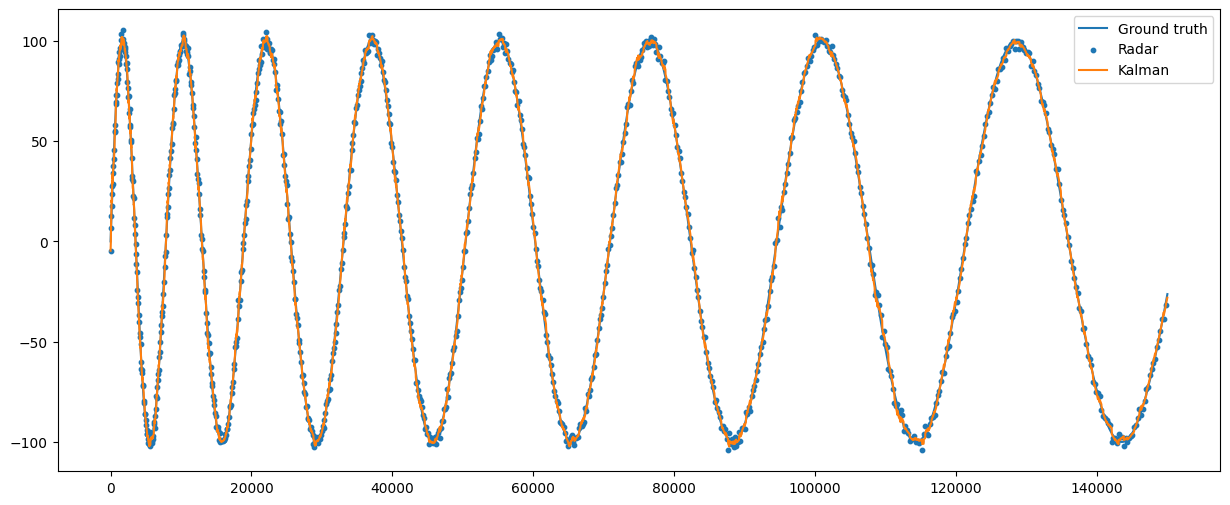

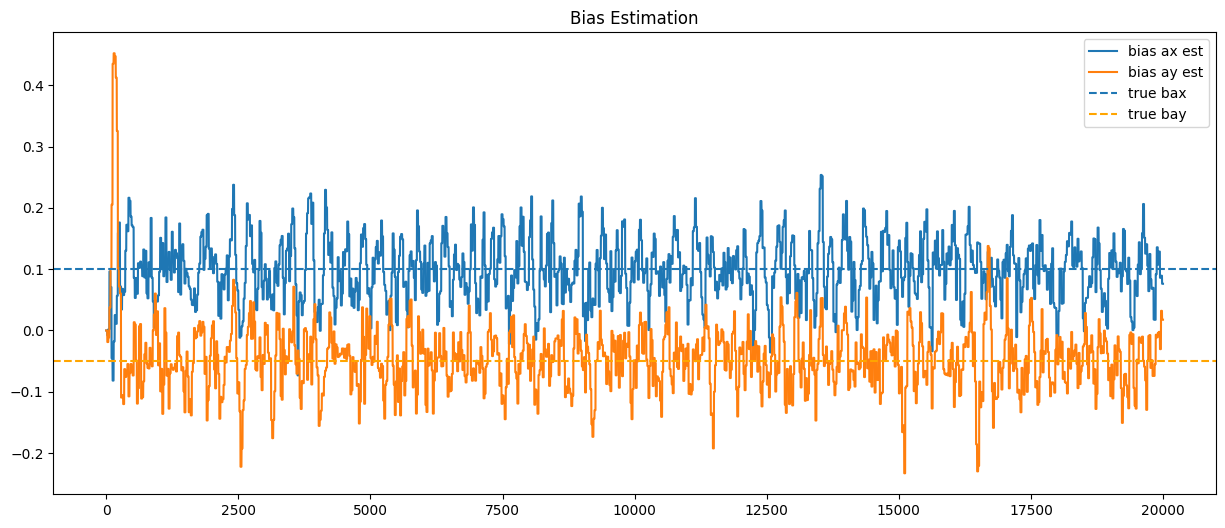

In [8]:
x0, P0, Q, H_pos, R_pos = init_kalman(z_gnss, vx[0], vy[0], config)
x_kalman = run_kalman_filter(t_gnss, t_imu, z_gnss, z_imu, x0, P0, Q, H_pos, R_pos).squeeze()

plt.figure(figsize = (15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(z_gnss[:,0], z_gnss[:,1], s= 10, label = "Radar")
plt.plot(x_kalman[:,0], x_kalman[:,1], label = "Kalman")
plt.legend()
plt.show()

plt.figure(figsize = (15, 6))
plt.plot(x_kalman[:,4], label="bias ax est")
plt.plot(x_kalman[:,5], label="bias ay est")
plt.axhline(0.1, linestyle="--", label="true bax")
plt.axhline(-0.05, linestyle="--", color = 'orange', label="true bay")
plt.legend()
plt.title("Bias Estimation")
plt.show()

In [9]:
def init_particles(z_gnss, vx0, vy0, config):
    
    N = config["N_particles"]
    
    sigma_pos = config["sigma_pos"]
    sigma_vel = config["sigma_vel"]
    sigma_bias = config["sigma_bias"]
    
    particles = np.zeros((N, 6))
    
    particles[:, 0] = z_gnss[0, 0] + np.random.randn(N) * sigma_pos
    particles[:, 1] = z_gnss[0, 1] + np.random.randn(N) * sigma_pos
    particles[:, 2] = vx0 + np.random.randn(N) * sigma_vel
    particles[:, 3] = vy0 + np.random.randn(N) * sigma_vel
    particles[:, 4:6] = np.random.randn(N, 2) * sigma_bias
    
    weights = np.ones(N) / N

    return particles, weights

In [10]:
def predict_particles(particles, z_imu, dt, config) :
    N = particles.shape[0]

    ax_meas = 0
    ay_meas = 0
    
    bax, bay = particles[:, 4], particles[:, 5]
    ax_corr = ax_meas - bax
    ay_corr = ay_meas - bay
        
    noise_pos = np.random.randn(N, 2) * config["e_p"]
    noise_vel = np.random.randn(N, 2) * config["e_v"]
    noise_bias = np.random.randn(N, 2) * config["e_b"]
    
    particles[:, 0] += particles[:, 2] * dt + 0.5 * ax_corr * dt**2 + noise_pos[:, 0]
    particles[:, 1] += particles[:, 3] * dt + 0.5 * ay_corr * dt**2 + noise_pos[:, 1]
    particles[:, 2] += ax_corr * dt + noise_vel[:, 0]
    particles[:, 3] += ay_corr * dt + noise_vel[:, 1]
    particles[:, 4] += noise_bias[:, 0]
    particles[:, 5] += noise_bias[:, 1]

    return particles

In [11]:
def update_weights_position(particles, weights, z_gnss, config) :
    x_pos = z_gnss[0]
    y_pos = z_gnss[1]
    
    dx = particles[:, 0] - x_pos
    dy = particles[:, 1] - y_pos
    d2_pos = dx**2 + dy**2

    log_w = -0.5 * (d2_pos / config["noise_gnss"]**2)
    log_w -= np.max(log_w)
    
    weights = np.exp(log_w)
    weights /= np.sum(weights)

    if np.sum(weights) == 0 or np.isnan(weights).any():
        weights.fill(1.0 / len(weights))

    return weights

In [12]:
def N_eff(weights) :
    return 1. / np.sum(weights**2)

In [13]:
def resample(particles, weights) :
    N = len(weights)
    positions = (np.arange(N) + np.random.rand()) / N

    indexes = np.zeros(N, dtype = int)
    cumulative_sum = np.cumsum(weights)
    i, j = 0, 0

    while i < N :
        if positions[i] < cumulative_sum[j] :
            indexes[i] = j
            i += 1  
        else :
            j += 1

    particles[:] = particles[indexes]
    weights.fill(1 / N)

    return particles, weights

In [14]:
def run_particle_filter(t_gnss, t_imu, z_gnss, z_imu, particles, weights, config) :

    estimates = []
    x_est0 = np.average(particles, weights=weights, axis=0)
    estimates.append(x_est0.copy())

    gnss_idx = 0
    
    for k in range(1, len(t_imu)) :
        dt = t_imu[k] - t_imu[k-1]
        
        particles = predict_particles(particles, z_imu[k], dt, config)

        if gnss_idx < len(t_gnss) and t_imu[k] >= t_gnss[gnss_idx] :
            weights = update_weights_position(particles, weights, z_gnss[gnss_idx], config)
            gnss_idx += 1
                
            if N_eff(weights) < config["N_particles"] * 0.5 :
                particles, weights = resample(particles, weights)
    
        x_hat = np.average(particles, weights = weights, axis = 0)
        estimates.append(x_hat.copy())
    return np.array(estimates)

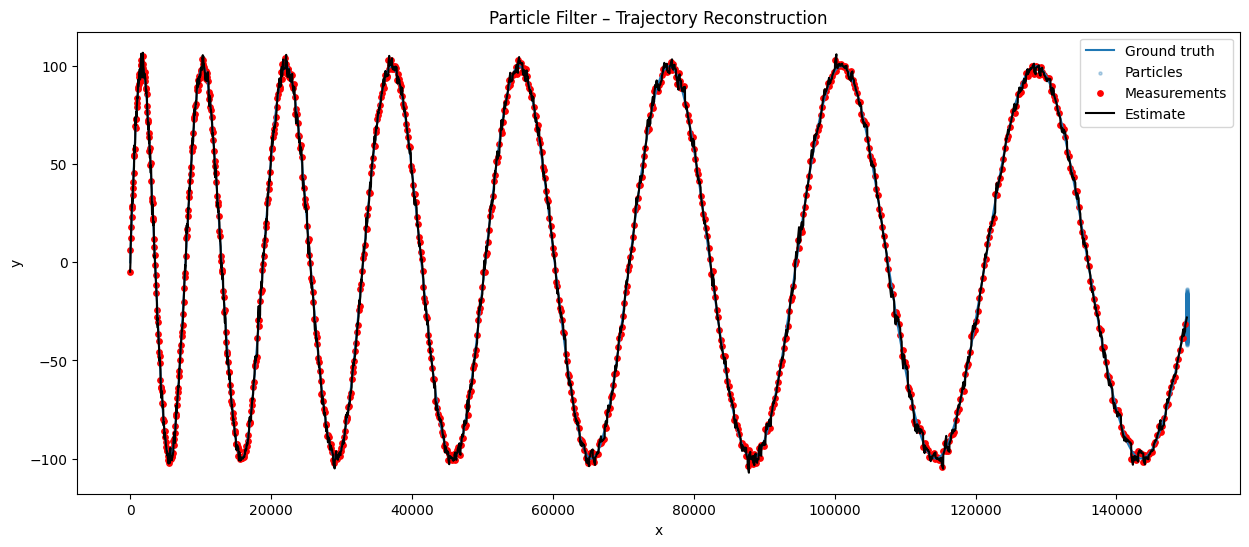

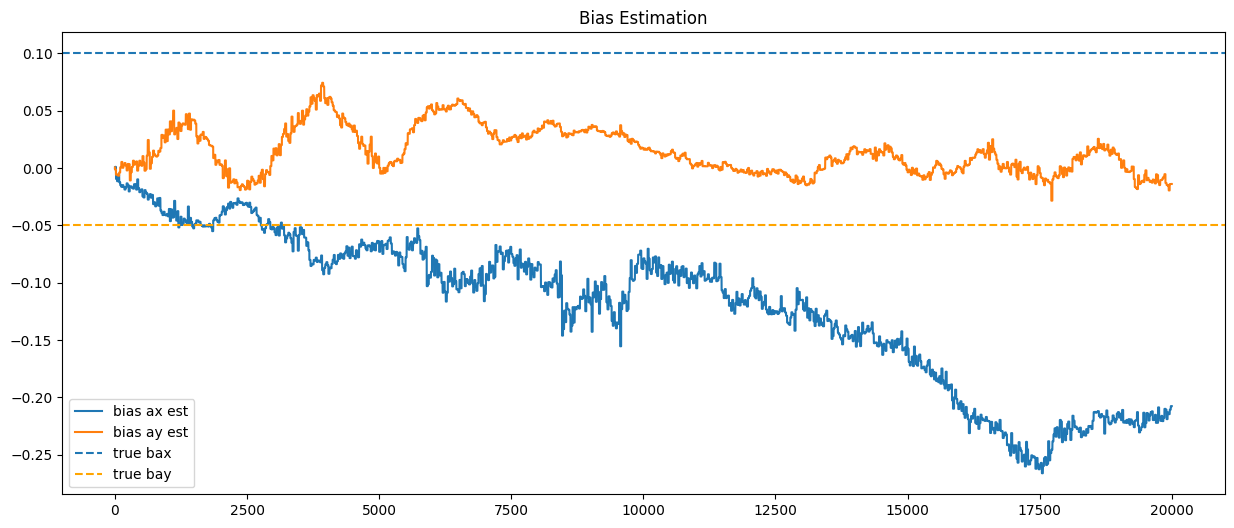

In [15]:
particles, weights = init_particles(z_gnss, vx[0], vy[0], config)
x_pf = run_particle_filter(t_gnss, t_imu, z_gnss, z_imu, particles, weights, config)

plt.figure(figsize=(15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(particles[:, 0], particles[:, 1], s = 5, alpha = 0.3, label = "Particles")
plt.scatter(z_gnss[:, 0], z_gnss[:, 1], c = "red", s = 15, label = "Measurements")
plt.plot(x_pf[:, 0], x_pf[:, 1], c = "black", label = "Estimate")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Particle Filter – Trajectory Reconstruction")
plt.show()

plt.figure(figsize = (15, 6))
plt.plot(x_pf[:,4], label="bias ax est")
plt.plot(x_pf[:,5], label="bias ay est")
plt.axhline(0.1, linestyle="--", label="true bax")
plt.axhline(-0.05, linestyle="--", color = 'orange', label="true bay")
plt.legend()
plt.title("Bias Estimation")
plt.show()

In [16]:
def rms_position(x_est, x_true) :
    error_pos = x_est[:, :2] - x_true[:, :2]
    return np.sqrt(np.mean(np.sum(error_pos**2, axis = 1)))

In [17]:
def rms_velocity( x_est, x_true) :
    error_vel = x_est[:, 2:4] - x_true[:, 2:4]
    return np.sqrt(np.mean(np.sum(error_vel**2, axis = 1)))

In [18]:
x_true = np.column_stack((
    np.interp(t_imu, t, x),
    np.interp(t_imu, t, y),
    np.interp(t_imu, t, vx),
    np.interp(t_imu, t, vy)
))

In [19]:
rms_kalman_pos = rms_position(x_kalman, x_true)
rms_pf_pos = rms_position(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_pos)
print("RMS Particle Filter: ", rms_pf_pos)

RMS Kalman:  2.0105328108590714
RMS Particle Filter:  3.125030770109422


In [20]:
rms_kalman_vel = rms_velocity(x_kalman, x_true)
rms_pf_vel = rms_velocity(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_vel)
print("RMS Particle Filter: ", rms_pf_vel)

RMS Kalman:  0.573644881665657
RMS Particle Filter:  1.7943140116683103


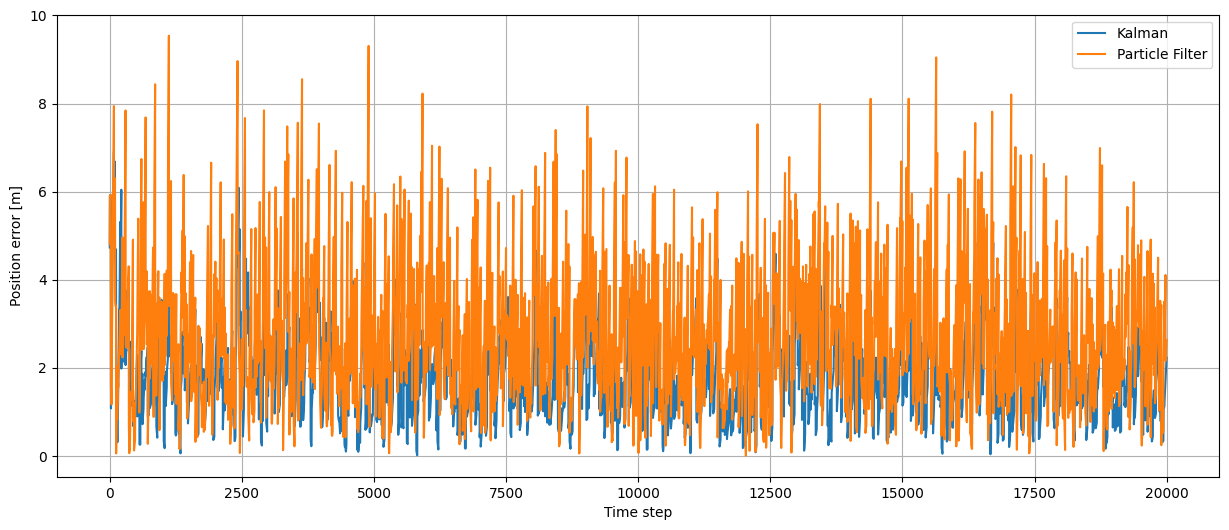

In [21]:
error_kalman = np.linalg.norm(x_kalman[:, :2] - x_true[:, :2], axis = 1)
error_pf = np.linalg.norm(x_pf[:, :2] - x_true[:, :2], axis = 1)

plt.figure(figsize = (15, 6))
plt.plot(error_kalman, label = "Kalman")
plt.plot(error_pf, label = "Particle Filter")
plt.xlabel("Time step")
plt.ylabel("Position error [m]")
plt.legend()
plt.grid()
plt.show()

In [22]:
def gnss_measurements_outliers(t_truth, x, y, noise_gnss, rate = 1, p_outlier = 0.1, outlier_scale_p = 10):
    dt_meas = 1/rate
    t_meas = np.arange(0, t_truth[-1], dt_meas)

    x_meas = np.interp(t_meas, t_truth, x)
    y_meas = np.interp(t_meas, t_truth, y)

    noise_pos = np.random.randn(len(t_meas), 2) * noise_gnss

    outliers = np.random.rand(len(t_meas)) < p_outlier
    noise_pos[outliers] += np.random.randn(np.sum(outliers), 2) * noise_gnss * outlier_scale_p
    
    z = np.column_stack((x_meas, y_meas)) + noise_pos
    return t_meas, z

t_gnss, z_gnss = gnss_measurements_outliers(t, x, y, config["noise_gnss"])

In [23]:
x0, P0, Q, H_pos, R_pos = init_kalman(z_gnss, vx[0], vy[0], config)
x_kalman = run_kalman_filter(t_gnss, t_imu, z_gnss, z_imu, x0, P0, Q, H_pos, R_pos).squeeze()

particles, weights = init_particles(z_gnss, vx[0], vy[0], config)
x_pf = run_particle_filter(t_gnss, t_imu, z_gnss, z_imu, particles, weights, config)

In [24]:
rms_kalman = rms_position(x_kalman, x_true)
rms_pf = rms_position(x_pf, x_true)

print("RMS Kalman: ", rms_kalman)
print("RMS Particle Filter: ", rms_pf)

RMS Kalman:  5.611897162791594
RMS Particle Filter:  7.793517705561455


In [25]:
rms_kalman_vel = rms_velocity(x_kalman, x_true)
rms_pf_vel = rms_velocity(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_vel)
print("RMS Particle Filter: ", rms_pf_vel)

RMS Kalman:  1.5079992342664392
RMS Particle Filter:  4.274648733460467


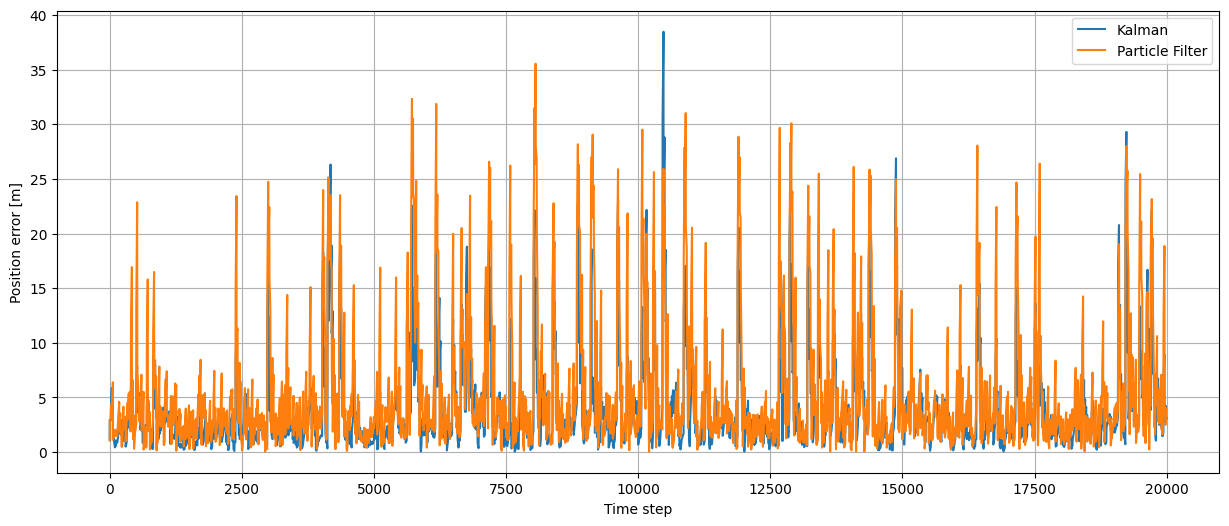

In [26]:
error_kalman = np.linalg.norm(x_kalman[:, :2] - x_true[:, :2], axis = 1)
error_pf = np.linalg.norm(x_pf[:, :2] - x_true[:, :2], axis = 1)

plt.figure(figsize = (15, 6))
plt.plot(error_kalman, label = "Kalman")
plt.plot(error_pf, label = "Particle Filter")
plt.xlabel("Time step")
plt.ylabel("Position error [m]")
plt.legend()
plt.grid()
plt.show()